In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.formula.api as smf
from lightgbm import LGBMRegressor
import sqlite3

In [102]:
conn = sqlite3.connect("fietstellingen.db")

In [103]:
query = """
SELECT *
FROM traffic_counts
"""

df = pd.read_sql_query(query, conn)

In [73]:
df.isnull().sum()

Site_ID                 0
Direction               0
Modus                   0
Start_Time              0
End_Time                0
Count             1085221
site_direction          0
dtype: int64

In [106]:
df[df["Count"].isna()].head(20)

,Site_ID,Direction,Modus,Start_Time,End_Time,Count
25857,Location_Tag_5,IN,FIETSERS,2019-08-22 08:15:00.0,2019-08-22 08:30:00.0,NaN
25858,Location_Tag_5,IN,FIETSERS,2019-08-22 08:30:00.0,2019-08-22 08:45:00.0,NaN
25859,Location_Tag_5,IN,FIETSERS,2019-08-22 08:45:00.0,2019-08-22 09:00:00.0,NaN
25860,Location_Tag_5,IN,FIETSERS,2019-08-22 09:00:00.0,2019-08-22 09:15:00.0,NaN
28833,Location_Tag_5,OUT,FIETSERS,2019-08-22 08:15:00.0,2019-08-22 08:30:00.0,NaN
28834,Location_Tag_5,OUT,FIETSERS,2019-08-22 08:30:00.0,2019-08-22 08:45:00.0,NaN
28835,Location_Tag_5,OUT,FIETSERS,2019-08-22 08:45:00.0,2019-08-22 09:00:00.0,NaN
28836,Location_Tag_5,OUT,FIETSERS,2019-08-22 09:00:00.0,2019-08-22 09:15:00.0,NaN
119040,Location_Tag_21,IN,FIETSERS,2019-08-26 03:00:00.0,2019-08-26 03:15:00.0,NaN
119041,Location_Tag_21,IN,FIETSERS,2019-08-26 03:15:00.0,2019-08-26 03:30:00.0,NaN


In [107]:
df[df["Count"].isna()]["Site_ID"].nunique()

150

In [76]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])
df["End_Time"] = pd.to_datetime(df["End_Time"])
df["site_direction"] = df["Site_ID"] + "_" + df["Direction"]

In [77]:
df_daily = df.dropna(subset=["Count"]).set_index("Start_Time").groupby("Site_ID").resample("D").agg({"Count": "sum"}).reset_index()


In [78]:
df_daily["Count"].isna().sum()

np.int64(0)

In [79]:
def add_time_features(data):
    data = data.copy()
    
    data["dayofweek"] = data["Start_Time"].dt.dayofweek
    data["month"] = data["Start_Time"].dt.month
    data["dayofyear"] = data["Start_Time"].dt.dayofyear
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)
    
    # yearly seasonality
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    data["doy_sin"] = np.sin(2 * np.pi * data["dayofyear"] / 365)
    data["doy_cos"] = np.cos(2 * np.pi * data["dayofyear"] / 365)
    
    return data

In [80]:
df_daily = add_time_features(df_daily)

In [81]:
df_daily["lag_1"] = df_daily.groupby("Site_ID")["Count"].shift(1)
df_daily["lag_7"] = df_daily.groupby("Site_ID")["Count"].shift(7)
df_daily["lag_14"] = df_daily.groupby("Site_ID")["Count"].shift(14)
df_daily["lag_28"] = df_daily.groupby("Site_ID")["Count"].shift(28)

df_model = df_daily.dropna().copy()

In [82]:
df_model.head()

,Site_ID,Start_Time,Count,dayofweek,month,dayofyear,is_weekend,month_sin,month_cos,doy_sin,doy_cos,lag_1,lag_7,lag_14,lag_28
28,Location_Tag_1,2019-08-29,499.0,3,8,241,0,-0.866025,-5.000000e-01,-0.845249,-0.534373,472.0,501.0,237.0,495.0
29,Location_Tag_1,2019-08-30,483.0,4,8,242,0,-0.866025,-5.000000e-01,-0.854322,-0.519744,499.0,431.0,291.0,364.0
30,Location_Tag_1,2019-08-31,292.0,5,8,243,1,-0.866025,-5.000000e-01,-0.863142,-0.504961,483.0,263.0,96.0,273.0
31,Location_Tag_1,2019-09-01,818.0,6,9,244,1,-1.000000,-1.836970e-16,-0.871706,-0.490029,292.0,382.0,151.0,424.0
32,Location_Tag_1,2019-09-02,537.0,0,9,245,0,-1.000000,-1.836970e-16,-0.880012,-0.474951,818.0,546.0,363.0,455.0


In [83]:
def split_train_test(cutoff="2025-05-16",forecast_end="2025-11-16",years=3,df=df_model):
    cutoff = pd.Timestamp(cutoff)
    forecast_end = pd.Timestamp(forecast_end)

    train_start = cutoff - pd.DateOffset(years=years)

    train = df[
        (df["Start_Time"] >= train_start) &
        (df_model["Start_Time"] <= cutoff)
    ].copy()

    test_actual = df[
        (df["Start_Time"] > cutoff) &
        (df["Start_Time"] <= forecast_end)
    ].copy()

    return train, test_actual

In [84]:
train_3Y, test_actual_3Y = split_train_test()

In [85]:
features = [
    "Site_ID",
    "dayofweek",
    "month",
    "dayofyear",
    "is_weekend",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28"
]

target = "Count"

In [86]:
train_3Y["Site_ID"] = train_3Y["Site_ID"].astype("category")

In [87]:
lgbm_model_3Y = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgbm_model_3Y.fit(
    train_3Y[features],
    train_3Y[target],
    categorical_feature=["Site_ID"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1960
[LightGBM] [Info] Number of data points in the train set: 141242, number of used features: 13
[LightGBM] [Info] Start training from score 485.562637


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [88]:
def recursive_forecast_lgbm(model, history, future_dates, features):
    history = history.copy()
    predictions = []

    sites = history["Site_ID"].unique()

    for date in future_dates:
        future_rows = pd.DataFrame({
            "Site_ID": sites,
            "Start_Time": date
        })

        future_rows = add_time_features(future_rows)

        for lag in [1, 7, 14, 28]:
            lag_values = (
                history[history["Start_Time"] == date - pd.Timedelta(days=lag)]
                [["Site_ID", "Count"]]
                .rename(columns={"Count": f"lag_{lag}"})
            )

            future_rows = future_rows.merge(
                lag_values,
                on="Site_ID",
                how="left"
            )

        future_rows = future_rows.dropna(subset=["lag_1", "lag_7", "lag_14", "lag_28"]).copy()

        future_rows["Site_ID"] = future_rows["Site_ID"].astype("category")

        future_rows["pred"] = model.predict(future_rows[features])

        # Count cannot be negative
        future_rows["pred"] = np.maximum(future_rows["pred"], 0)

        append_rows = future_rows[["Site_ID", "Start_Time", "pred"]].rename(
            columns={"pred": "Count"}
        )

        history = pd.concat([history, append_rows], ignore_index=True)

        predictions.append(future_rows)

    return pd.concat(predictions, ignore_index=True)

In [89]:
def func_predict(lgbm_model,test_actual,cutoff="2025-05-16",forecast_end="2025-11-16",df_daily=df_daily):

    future_dates = pd.date_range(
        start= pd.Timestamp(cutoff) + pd.Timedelta(days=1),
        end= pd.Timestamp(forecast_end),
        freq="D"
    )

    history = df_daily[
        df_daily["Start_Time"] <= cutoff
    ][["Site_ID", "Start_Time", "Count"]].copy()

    pred_eval = recursive_forecast_lgbm(
        model=lgbm_model,
        history=history,
        future_dates=future_dates,
        features=features
    )

    eval_df = pred_eval.merge(
        test_actual[["Site_ID", "Start_Time", "Count"]],
        on=["Site_ID", "Start_Time"],
        how="inner"
    )

    eval_df = eval_df.rename(columns={"Count": "actual"})

    mae_lgbm = mean_absolute_error(eval_df["actual"], eval_df["pred"])
    rmse_lgbm = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["pred"]))

    print("Recursive LightGBM MAE:", mae_lgbm)
    print("Recursive LightGBM RMSE:", rmse_lgbm)

    return eval_df

In [90]:
eval_df_3Y = func_predict(lgbm_model_3Y, test_actual_3Y)

Recursive LightGBM MAE: 186.48187933449387
Recursive LightGBM RMSE: 425.74743638008886


In [91]:
test_actual_3Y['Count'].describe()

count    25691.000000
mean       608.108949
std        793.881260
min          0.000000
25%        189.000000
50%        388.000000
75%        709.000000
max      11465.000000
Name: Count, dtype: float64

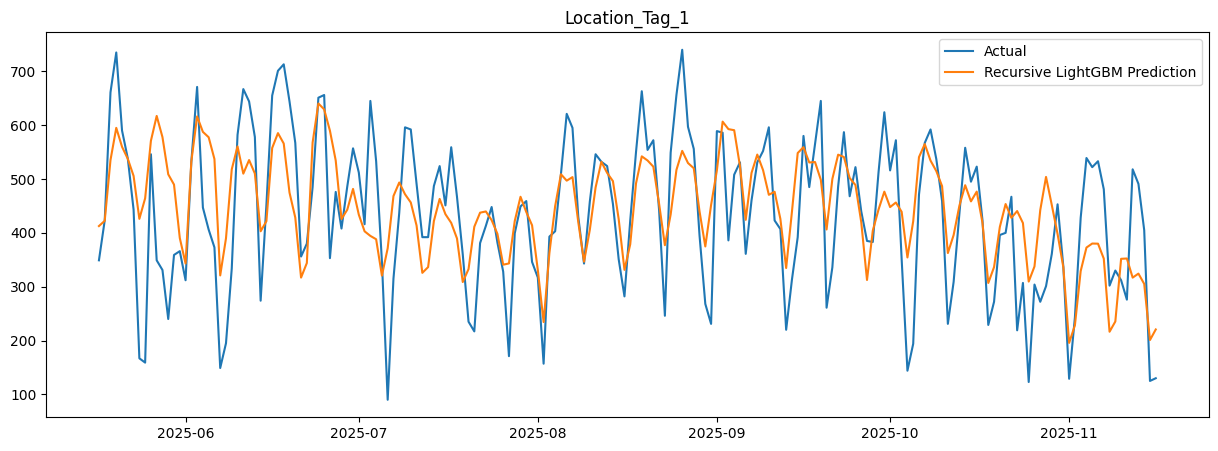

In [92]:
example_site = eval_df_3Y["Site_ID"].iloc[0]

plot_df = eval_df_3Y[eval_df_3Y["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction")

plt.title(example_site)
plt.legend()
plt.show()

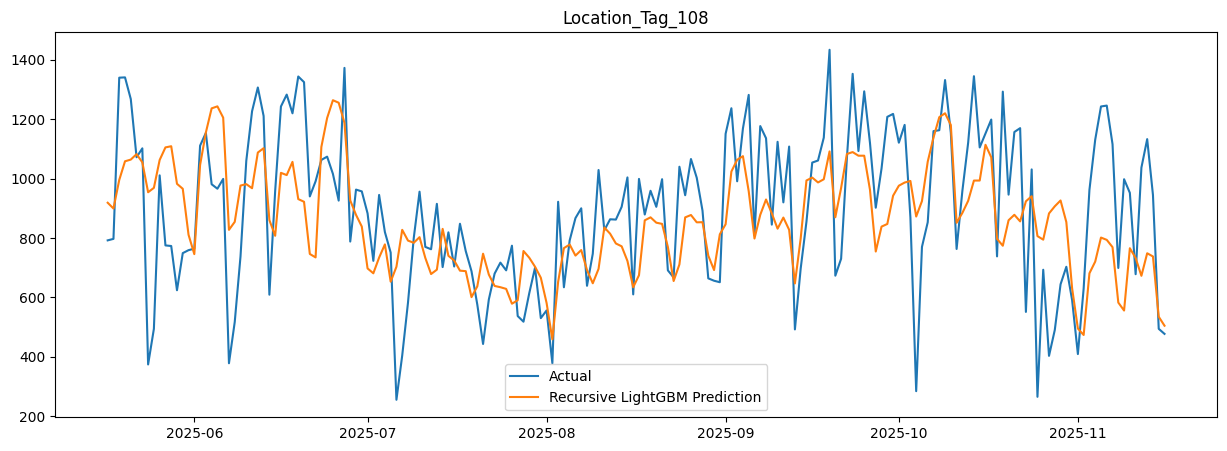

In [93]:
example_site = eval_df_3Y["Site_ID"].iloc[10]

plot_df = eval_df_3Y[eval_df_3Y["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction")

plt.title(example_site)
plt.legend()
plt.show()

In [42]:
# Recursive LightGBM MAE: 186.48187933449387
# Recursive LightGBM RMSE: 425.74743638008886

# Recursive FEM MAE: 230.90112501592827
# Recursive FEM RMSE: 493.5936794287685

## 2Y

In [94]:
train_2Y, test_actual_2Y = split_train_test(years=2)

In [95]:
train_2Y["Site_ID"] = train_2Y["Site_ID"].astype("category")

In [96]:
lgbm_model_2Y = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgbm_model_2Y.fit(
    train_2Y[features],
    train_2Y[target],
    categorical_feature=["Site_ID"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1968
[LightGBM] [Info] Number of data points in the train set: 102072, number of used features: 13
[LightGBM] [Info] Start training from score 513.832148


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [97]:
eval_df_2Y = func_predict(lgbm_model_2Y, test_actual_2Y)

Recursive LightGBM MAE: 186.74365464048708
Recursive LightGBM RMSE: 422.3212770477951


In [98]:
test_actual_2Y['Count'].describe()

count    25691.000000
mean       608.108949
std        793.881260
min          0.000000
25%        189.000000
50%        388.000000
75%        709.000000
max      11465.000000
Name: Count, dtype: float64

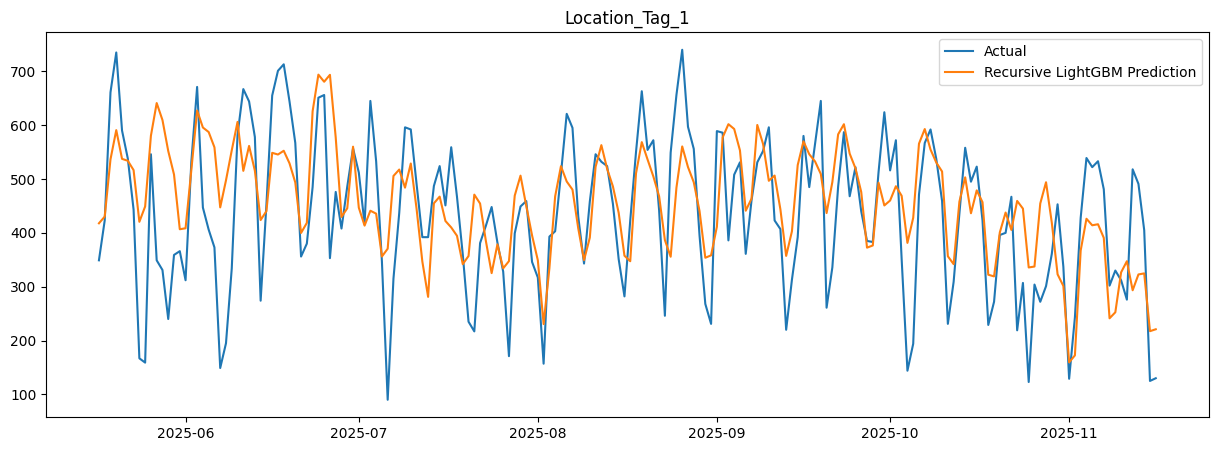

In [72]:
example_site = eval_df_2Y["Site_ID"].iloc[0]

plot_df = eval_df_2Y[eval_df_2Y["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction")

plt.title(example_site)
plt.legend()
plt.show()

In [99]:
eval_df_2Y

,Site_ID,Start_Time,dayofweek,month,dayofyear,is_weekend,month_sin,month_cos,doy_sin,doy_cos,lag_1,lag_7,lag_14,lag_28,pred,actual
0,Location_Tag_1,2025-05-17,5,5,137,1,0.5,-0.866025,0.705584,-0.708627,570.000000,414.000000,280.000000,305.000000,417.743894,349.0
1,Location_Tag_10,2025-05-17,5,5,137,1,0.5,-0.866025,0.705584,-0.708627,592.000000,384.000000,257.000000,372.000000,433.204987,300.0
2,Location_Tag_100,2025-05-17,5,5,137,1,0.5,-0.866025,0.705584,-0.708627,2718.000000,1729.000000,1670.000000,1361.000000,1835.985794,1504.0
3,Location_Tag_101,2025-05-17,5,5,137,1,0.5,-0.866025,0.705584,-0.708627,481.000000,498.000000,353.000000,364.000000,425.239302,380.0
4,Location_Tag_102,2025-05-17,5,5,137,1,0.5,-0.866025,0.705584,-0.708627,371.000000,445.000000,260.000000,309.000000,347.229547,344.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25203,Location_Tag_93,2025-11-16,6,11,320,1,-0.5,0.866025,-0.699458,0.714673,179.979172,183.796167,125.851182,259.786968,171.716663,137.0
25204,Location_Tag_94,2025-11-16,6,11,320,1,-0.5,0.866025,-0.699458,0.714673,233.610117,261.066565,176.605093,361.299401,229.407618,202.0
25205,Location_Tag_97,2025-11-16,6,11,320,1,-0.5,0.866025,-0.699458,0.714673,189.677130,161.961032,68.331442,227.317275,140.687537,118.0
25206,Location_Tag_98,2025-11-16,6,11,320,1,-0.5,0.866025,-0.699458,0.714673,204.400558,167.016751,96.836514,238.228587,151.935546,133.0
